## Customer Churn Prediction and Retention Analysis

### Data Understanding and Initial EDA

Objective:This notebook performs the initial data understanding and exploratory data analysis of the IBM Telco Customer Churn dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
%pip install openpyxl

#python -m pip install openpyxl (in terminal)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
file_path = "../data/raw/Telco_customer_churn.xlsx"
df = pd.read_excel(file_path)
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [6]:
# dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 33


In [8]:
# Data Types and Structure
# Understanding the data types of each feature is an important step before preprocessing. Numerical, categorical, identifier, and target variables require different preprocessing techniques.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [9]:
df.dtypes.value_counts()

object     24
int64       6
float64     3
Name: count, dtype: int64

In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()
print("Numerical columns:")
print(numerical_columns)
print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']

Categorical columns:
['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn Label', 'Churn Reason']


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [12]:
#Missing Value Analysis:
#Missing values can affect statistical analysis and machine learning model performance.
#This section identifies missing values in each feature before any imputation or removal is performed.

#Calculate the total number of missing values in the dataset
total_missing = df.isnull().sum().sum()
print("Total missing values:", total_missing)

Total missing values: 5174


In [13]:
# Count missing values in each column
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Churn Reason    5174
dtype: int64


In [15]:
# Calculate missing-value percentage for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': missing_percentage
})
missing_summary = missing_summary[
    missing_summary['Missing Values'] > 0
].sort_values(
    by='Missing Percentage',
    ascending=False
)
missing_summary

,Missing Values,Missing Percentage
Churn Reason,5174,73.463013


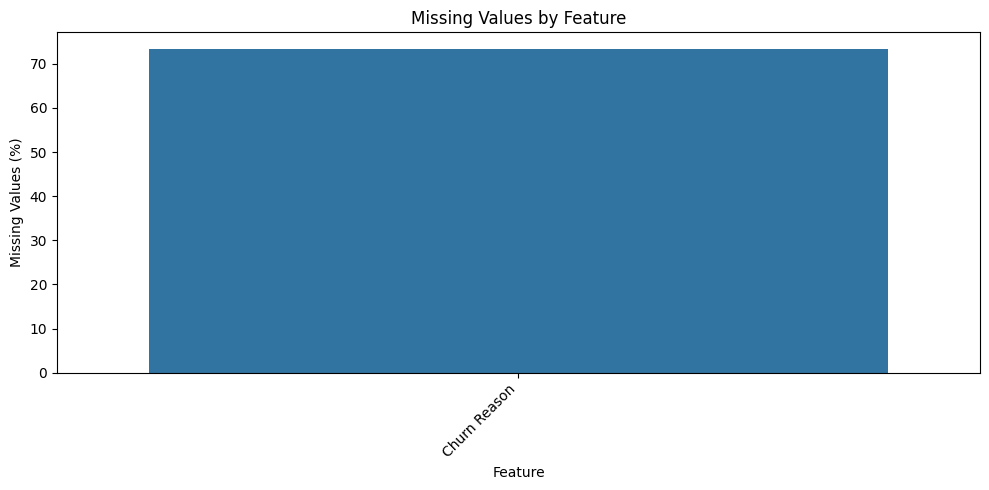

In [16]:
# Visualize columns containing missing values
if not missing_summary.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=missing_summary.index,
        y=missing_summary['Missing Percentage']
    )

    plt.title('Missing Values by Feature')
    plt.xlabel('Feature')
    plt.ylabel('Missing Values (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")

In [17]:
# Check for blank or whitespace-only strings
blank_values = {}

for column in df.select_dtypes(include='object').columns:
    blanks = df[column].astype(str).str.strip().eq('').sum()
    if blanks > 0:
        blank_values[column] = blanks

print("Blank string values:")
print(blank_values)

Blank string values:
{'Total Charges': 11}


In [18]:
#Duplicate Record Analysis
#Check for completely duplicated rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


#### Target Variable Analysis

The target variable represents whether a customer has churned. Understanding its distribution is essential for determining the nature of the classification problem and identifying potential class imbalance.
In this project, `Churn Label` will be considered as the primary target variable because it directly represents the customer's churn status.

In [ ]:
# Count customers in each churn category
churn_counts = df['Churn Label'].value_counts()
print("Customer Churn Distribution:")
print(churn_counts)

Customer Churn Distribution:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [20]:
# Calculate the percentage distribution of the target variable
churn_percentage = df['Churn Label'].value_counts(normalize=True) * 100

print("Customer Churn Percentage:")
print(churn_percentage.round(2))

Customer Churn Percentage:
Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


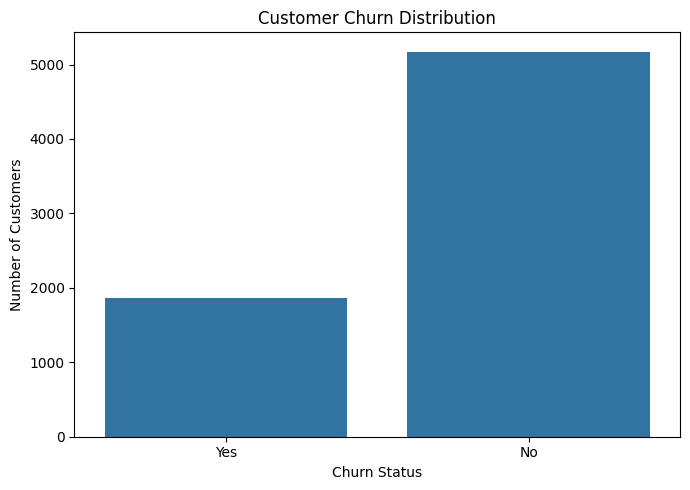

In [21]:
# Visualize customer churn distribution
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Churn Label')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

#### Interpretation

The target variable shows that 5,174 customers (73.46%) did not churn, while 1,869 customers (26.54%) churned.

The distribution indicates a moderate class imbalance, with non-churned customers representing the majority class. This imbalance should be considered during model development because a model that predicts most customers as non-churned could achieve relatively high accuracy while performing poorly at identifying actual churners.

Therefore, model evaluation will place particular emphasis on recall, precision, F1-score, ROC-AUC, and the confusion matrix rather than relying on accuracy alone. Class imbalance handling techniques such as class weighting or resampling will be evaluated during the preprocessing and model development stages.

In [22]:
# Numerical Feature Analysis
# Numerical features provide quantitative information about customer characteristics and account behavior. This section examines the distribution of important numerical variables and explores their relationship with customer churn.
# Define the main numerical features for initial analysis
numerical_features = [
    'Tenure Months',
    'Monthly Charges',
    'Total Charges',
    'CLTV'
]

# Display summary statistics
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure Months,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
Monthly Charges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75
CLTV,7043.0,4400.295755,1183.057152,2003.00,3469.0,4527.00,5380.50,6500.00


In [23]:
# Compare numerical features between churned and non-churned customers
df.groupby('Churn Label')[numerical_features[:2]].mean().round(2)

,Tenure Months,Monthly Charges
Churn Label,,
No,37.57,61.27
Yes,17.98,74.44


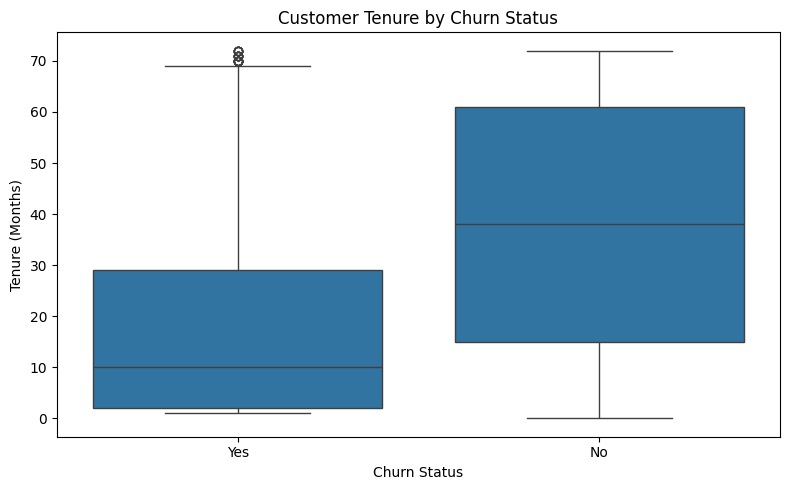

In [24]:
# Distribution of customer tenure by churn status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn Label',
    y='Tenure Months'
)

plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')

plt.tight_layout()
plt.show()